<a href="https://colab.research.google.com/github/KRBAI/Assignment-1/blob/main/Question7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 7

SSD (Nearest): 0.01020
SSD (Bilinear): 0.00562


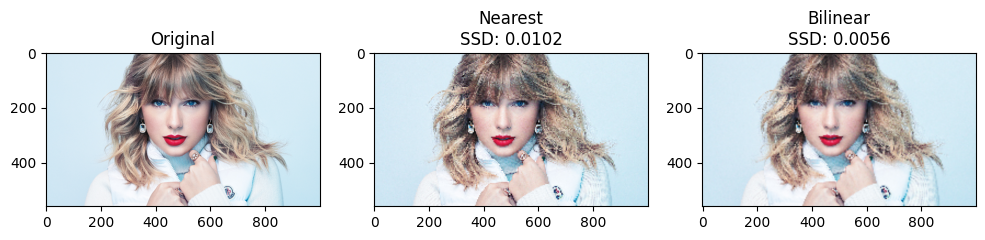

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def nearest_neighbor_zoom(img, scale):
    h, w = img.shape[:2]
    new_h, new_w = int(h * scale), int(w * scale)

    # 1. Create grid for new image
    x_new = np.arange(new_w)
    y_new = np.arange(new_h)

    # 2. Find corresponding coordinates in old image
    x_old = (x_new / scale).astype(int)
    y_old = (y_new / scale).astype(int)

    # Clip to bounds
    x_old = np.clip(x_old, 0, w - 1)
    y_old = np.clip(y_old, 0, h - 1)

    # 3. Vectorized mapping
    # np.meshgrid creates the 2D grid of indices
    xv, yv = np.meshgrid(x_old, y_old)

    # This works for both Gray and Color images automatically
    return img[yv, xv]

def bilinear_zoom(img, scale):
    h, w = img.shape[:2]
    new_h, new_w = int(h * scale), int(w * scale)

    # 1. Coordinate mapping (float)
    x_src = np.arange(new_w) / scale
    y_src = np.arange(new_h) / scale
    x_grid, y_grid = np.meshgrid(x_src, y_src)

    # 2. Get integer coordinates of 4 corners
    x1 = np.floor(x_grid).astype(int)
    y1 = np.floor(y_grid).astype(int)
    x2 = np.clip(x1 + 1, 0, w - 1)
    y2 = np.clip(y1 + 1, 0, h - 1)
    x1 = np.clip(x1, 0, w - 1)
    y1 = np.clip(y1, 0, h - 1)

    # 3. Calculate weights (distances)
    alpha = x_grid - x1
    beta = y_grid - y1

    # Fix for Color: Expand dimensions to (H, W, 1) so math works on (H, W, 3)
    if img.ndim == 3:
        alpha = alpha[..., None]
        beta = beta[..., None]

    # 4. Get pixel values
    A = img[y1, x1]
    B = img[y1, x2]
    C = img[y2, x1]
    D = img[y2, x2]

    # 5. Interpolate
    # f(x,y) = weighted sum of A, B, C, D
    top = (1 - alpha) * A + alpha * B
    bottom = (1 - alpha) * C + alpha * D
    final = (1 - beta) * top + beta * bottom

    return final.astype(np.uint8)

def compute_ssd(img1, img2):
    # Crop to match smallest dimensions (handles rounding errors)
    h = min(img1.shape[0], img2.shape[0])
    w = min(img1.shape[1], img2.shape[1])

    diff = img1[:h, :w].astype(float) - img2[:h, :w].astype(float)
    return np.sum(diff ** 2) / np.sum(img1[:h, :w].astype(float)**2)

# --- Main Execution ---
# 1. Load Color Image (Remove the '0' flag to keep it BGR)
img = cv2.imread('/content/drive/MyDrive/Assignment1/taylor.jpg')

# 2. Downscale first to simulate a low-res input
small = cv2.resize(img, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_NEAREST)

# 3. Zoom back up (4x)
zoom_nn = nearest_neighbor_zoom(small, 4)
zoom_bl = bilinear_zoom(small, 4)

# 4. Compare
ssd_nn = compute_ssd(img, zoom_nn)
ssd_bl = compute_ssd(img, zoom_bl)

print(f"SSD (Nearest): {ssd_nn:.5f}")
print(f"SSD (Bilinear): {ssd_bl:.5f}")

# 5. Display (Convert BGR to RGB for matplotlib)
plt.figure(figsize=(12, 6))
plt.subplot(131), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original')
plt.subplot(132), plt.imshow(cv2.cvtColor(zoom_nn, cv2.COLOR_BGR2RGB)), plt.title(f'Nearest\nSSD: {ssd_nn:.4f}')
plt.subplot(133), plt.imshow(cv2.cvtColor(zoom_bl, cv2.COLOR_BGR2RGB)), plt.title(f'Bilinear\nSSD: {ssd_bl:.4f}')
plt.show()